# Импорты

In [1]:
!pip install optuna openpyxl joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.5 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

## Загрузка и исследование данных

In [3]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR
ARTIFACTS_DIR = NOTEBOOK_DIR
ARTIFACTS_DIR.mkdir(exist_ok=True)

DATA_PATH = None
SHEET_NAME = 'tickets'

if DATA_PATH is None:
    excel_files = sorted(list(DATA_DIR.glob('*.xlsx')) + list(DATA_DIR.glob('*.xls')))
    if not excel_files:
        raise FileNotFoundError(
            f'В папке {DATA_DIR} не найден Excel-файл. '
            'Положите файл в data или задайте DATA_PATH вручную.'
        )
    DATA_PATH = excel_files[0]

DATA_PATH

PosixPath('/content/nerd_analytics_v25.xlsx')

In [4]:
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
df_raw.head()

,id,client_id,responsible_id,product,status,priority,date,deadline,closed_at,reopened_count,last_reopened_at,ai_suggested_category,final_category,is_admin_changed,keywords,confidence,sla_ttfr_min,sla_ttr_min
0,ccbfdf1a-deaa-456b-b8c8-38d24a512664,5927cb85-60a6-442f-8579-baa0b2661cc5,0dccc85e-ff8c-4b89-a2e5-2d68a450e266,платёжный сервис,reopened,high,2025-08-13 21:10:17,2025-10-27 21:10:17,NaT,1,2025-11-01 13:14:58,жалоба на сервис,вопрос по оплате,True,"тариф, списание, счёт",0.9830,30,480
1,84fd58d8-ce4c-4faa-897d-40f6f78cd699,a1c84659-92c0-4ee9-80fb-766304fd14d7,54e42d8a-6607-4c33-9b55-938329d3c056,API интеграция,open,high,2025-09-30 21:08:17,2026-03-10 21:08:17,NaT,0,NaN,запрос возврата,запрос возврата,False,"возврат, вернуть, ошибочный платёж",0.7102,30,480
2,a62f284b-f586-43b0-a31a-e974cdf265aa,1ae1510f-b1c5-4f88-a6dc-f42ead480686,98a7ad04-976f-4a1f-9a4e-2cc4d7cc73a1,аналитический модуль,reopened,low,2026-02-19 21:08:17,2026-02-22 21:08:17,NaT,3,2026-02-19 05:08:45,жалоба на сервис,жалоба на сервис,False,"долго, грубость, жалоба",0.8604,480,4320
3,e8273333-012f-440b-82bf-e07f36f49c22,290d88d2-7b11-41cf-8a63-aee8db6b85cd,98a7ad04-976f-4a1f-9a4e-2cc4d7cc73a1,личный кабинет,in_progress,high,2026-04-13 21:03:17,2026-12-25 21:03:17,NaT,0,NaN,технический сбой,технический сбой,False,"не работает, 500, недоступен",0.6413,30,480
4,605ea9ad-4877-4ed0-85a9-877ee438d3ca,73f9d39e-8f97-4c3b-a4db-7ae3cc0fd05f,30800edf-4d58-43e3-a96b-940fd74841ac,личный кабинет,closed,medium,2026-05-16 21:07:17,2026-08-28 21:07:17,2026-05-16 22:43:17,0,NaN,технический сбой,технический сбой,False,"сбой, ошибка, недоступен",0.7715,120,1440


In [5]:
df_raw.shape, df_raw.columns.tolist()

((3000, 18),
 ['id',
  'client_id',
  'responsible_id',
  'product',
  'status',
  'priority',
  'date',
  'deadline',
  'closed_at',
  'reopened_count',
  'last_reopened_at',
  'ai_suggested_category',
  'final_category',
  'is_admin_changed',
  'keywords',
  'confidence',
  'sla_ttfr_min',
  'sla_ttr_min'])

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     3000 non-null   object        
 1   client_id              3000 non-null   object        
 2   responsible_id         3000 non-null   object        
 3   product                3000 non-null   object        
 4   status                 3000 non-null   object        
 5   priority               3000 non-null   object        
 6   date                   3000 non-null   datetime64[ns]
 7   deadline               3000 non-null   datetime64[ns]
 8   closed_at              735 non-null    datetime64[ns]
 9   reopened_count         3000 non-null   int64         
 10  last_reopened_at       758 non-null    object        
 11  ai_suggested_category  3000 non-null   object        
 12  final_category         3000 non-null   object        
 13  is_

In [7]:
df_raw.isna().mean().sort_values(ascending=False).head(20)

,0
closed_at,0.755000
last_reopened_at,0.747333
client_id,0.000000
id,0.000000
status,0.000000
responsible_id,0.000000
priority,0.000000
date,0.000000
deadline,0.000000
product,0.000000


In [8]:
PRODUCT_COL = 'product'
CATEGORY_COL = 'final_category'

DATE_COL = 'date'

required_cols = [DATE_COL, PRODUCT_COL, CATEGORY_COL]

In [9]:
df = df_raw[[DATE_COL, PRODUCT_COL, CATEGORY_COL]].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
df[PRODUCT_COL] = df[PRODUCT_COL].fillna('unknown').astype(str)
df[CATEGORY_COL] = df[CATEGORY_COL].fillna('unknown').astype(str)
df = df.dropna(subset=[DATE_COL])
df['date'] = df[DATE_COL].dt.floor('D')
df['series_id'] = df[PRODUCT_COL] + ' | ' + df[CATEGORY_COL]

print('Строк после очистки:', len(df))
print('Период:', df['date'].min(), '-', df['date'].max())
print('Продуктов:', df[PRODUCT_COL].nunique())
print('Категорий:', df[CATEGORY_COL].nunique())
print('Рядов product-final_category:', df['series_id'].nunique())

Строк после очистки: 3000
Период: 2025-07-23 00:00:00 - 2026-05-18 00:00:00
Продуктов: 6
Категорий: 8
Рядов product-final_category: 48


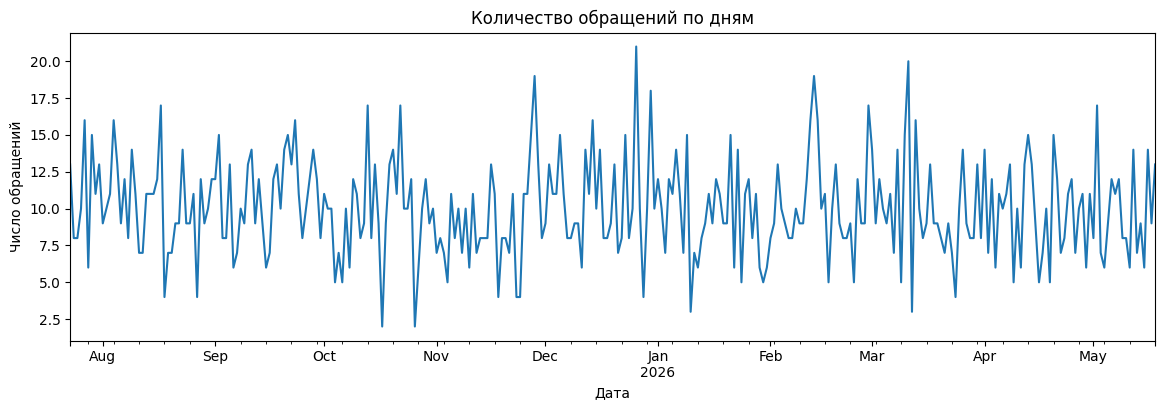

In [10]:
df.groupby('date').size().rename('tickets').plot(figsize=(14, 4), title='Количество обращений по дням')
plt.xlabel('Дата')
plt.ylabel('Число обращений')
plt.show()

In [11]:
top_series = df.groupby([PRODUCT_COL, CATEGORY_COL]).size().sort_values(ascending=False).head(20)
top_series.to_frame('tickets')

tickets
product              final_category            
аналитический модуль технический сбой        81
                     вопрос по оплате        79
платёжный сервис     ошибка в данных         76
веб-сервис           ошибка в данных         76
мобильное приложение консультация            73
аналитический модуль запрос документов       72
личный кабинет       запрос возврата         71
API интеграция       технический сбой        70
личный кабинет       технический сбой        69
                     консультация            68
платёжный сервис     технический сбой        68
мобильное приложение технический сбой        68
API интеграция       консультация            68
                     запрос возврата         68
                     ошибка в данных         68
веб-сервис           запрос возврата         67
мобильное приложение ошибка в данных         65
аналитический модуль жалоба на сервис        64
платёжный сервис     жалоба на сервис        64
                     консультация            64

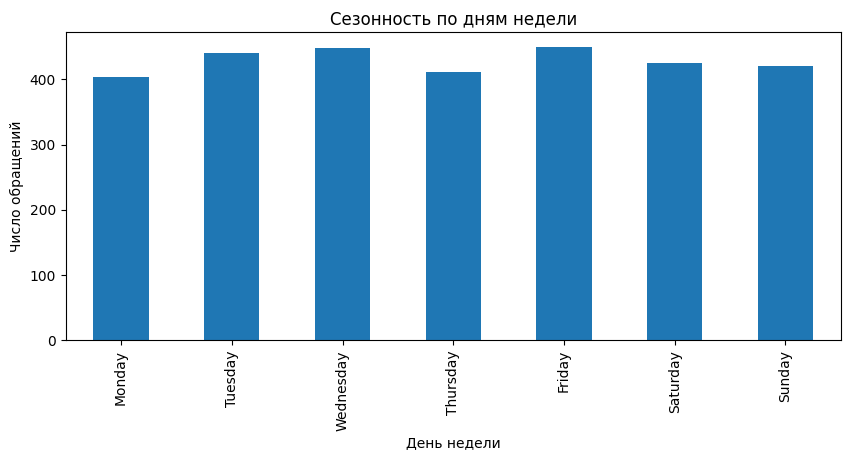

In [12]:
weekday_stats = (
    df.assign(weekday=df['date'].dt.day_name())
    .groupby('weekday')
    .size()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)
weekday_stats.plot(kind='bar', figsize=(10, 4), title='Сезонность по дням недели')
plt.xlabel('День недели')
plt.ylabel('Число обращений')
plt.show()

## Подготовка временных рядов

In [13]:
START_DATE = df['date'].min()
END_DATE = df['date'].max()
all_dates = pd.date_range(START_DATE, END_DATE, freq='D')
series_keys = df[[PRODUCT_COL, CATEGORY_COL, 'series_id']].drop_duplicates().sort_values(['series_id'])

calendar = (
    series_keys.assign(key=1)
    .merge(pd.DataFrame({'date': all_dates, 'key': 1}), on='key')
    .drop(columns='key')
)

daily = (
    df.groupby(['date', PRODUCT_COL, CATEGORY_COL, 'series_id'])
    .size()
    .rename('tickets')
    .reset_index()
)

ts = calendar.merge(daily, on=['date', PRODUCT_COL, CATEGORY_COL, 'series_id'], how='left')
ts['tickets'] = ts['tickets'].fillna(0).astype(int)
ts = ts.sort_values(['series_id', 'date']).reset_index(drop=True)

ts.head()

,product,final_category,series_id,date,tickets
0,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-07-23,1
1,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-07-24,0
2,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-07-25,0
3,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-07-26,0
4,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-07-27,0


In [14]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    result['dayofweek'] = result['date'].dt.dayofweek
    result['dayofmonth'] = result['date'].dt.day
    result['weekofyear'] = result['date'].dt.isocalendar().week.astype(int)
    result['month'] = result['date'].dt.month
    result['quarter'] = result['date'].dt.quarter
    result['is_month_start'] = result['date'].dt.is_month_start.astype(int)
    result['is_month_end'] = result['date'].dt.is_month_end.astype(int)
    result['is_weekend'] = result['dayofweek'].isin([5, 6]).astype(int)
    result['days_from_start'] = (result['date'] - result['date'].min()).dt.days

    result['dow_sin'] = np.sin(2 * np.pi * result['dayofweek'] / 7)
    result['dow_cos'] = np.cos(2 * np.pi * result['dayofweek'] / 7)
    result['month_sin'] = np.sin(2 * np.pi * result['month'] / 12)
    result['month_cos'] = np.cos(2 * np.pi * result['month'] / 12)
    return result


def add_aggregate_history_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()

    daily_total = result.groupby('date', as_index=False)['tickets'].sum(min_count=1).sort_values('date')
    shifted_total = daily_total['tickets'].shift(1)
    daily_total['global_lag_1'] = shifted_total
    daily_total['global_rolling_mean_7'] = shifted_total.rolling(7).mean()
    daily_total['global_rolling_mean_28'] = shifted_total.rolling(28).mean()
    result = result.merge(daily_total.drop(columns='tickets'), on='date', how='left')

    for group_col, prefix in [(PRODUCT_COL, 'product'), (CATEGORY_COL, 'category')]:
        aggregate = (
            result.groupby([group_col, 'date'], as_index=False)['tickets']
            .sum(min_count=1)
            .sort_values([group_col, 'date'])
        )
        shifted = aggregate.groupby(group_col)['tickets'].shift(1)
        aggregate[f'{prefix}_lag_1'] = shifted
        aggregate[f'{prefix}_rolling_mean_7'] = shifted.groupby(aggregate[group_col]).rolling(7).mean().reset_index(level=0, drop=True)
        aggregate[f'{prefix}_rolling_mean_28'] = shifted.groupby(aggregate[group_col]).rolling(28).mean().reset_index(level=0, drop=True)
        result = result.merge(aggregate.drop(columns='tickets'), on=[group_col, 'date'], how='left')

    return result


def add_lag_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.sort_values(['series_id', 'date']).copy()
    grouped = result.groupby('series_id')['tickets']

    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 35, 42, 56]:
        result[f'lag_{lag}'] = grouped.shift(lag)

    shifted = grouped.shift(1)
    for window in [3, 7, 14, 28, 56]:
        rolling = shifted.groupby(result['series_id']).rolling(window)
        result[f'rolling_mean_{window}'] = rolling.mean().reset_index(level=0, drop=True)
        result[f'rolling_median_{window}'] = rolling.median().reset_index(level=0, drop=True)
        result[f'rolling_std_{window}'] = rolling.std().reset_index(level=0, drop=True)
        result[f'rolling_min_{window}'] = rolling.min().reset_index(level=0, drop=True)
        result[f'rolling_max_{window}'] = rolling.max().reset_index(level=0, drop=True)
        result[f'rolling_nonzero_share_{window}'] = (
            shifted.gt(0).astype(float)
            .groupby(result['series_id'])
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )

    result['ewm_mean_7'] = shifted.groupby(result['series_id']).transform(lambda s: s.ewm(span=7, adjust=False).mean())
    result['ewm_mean_28'] = shifted.groupby(result['series_id']).transform(lambda s: s.ewm(span=28, adjust=False).mean())
    result['diff_1'] = result['lag_1'] - result['lag_2']
    result['diff_7'] = result['lag_7'] - result['lag_14']
    result['ratio_lag_1_to_mean_7'] = result['lag_1'] / (result['rolling_mean_7'] + 1)
    result['ratio_mean_7_to_mean_28'] = result['rolling_mean_7'] / (result['rolling_mean_28'] + 1)
    result['expanding_mean'] = shifted.groupby(result['series_id']).expanding().mean().reset_index(level=0, drop=True)
    result['expanding_nonzero_share'] = (
        shifted.gt(0).astype(float)
        .groupby(result['series_id'])
        .expanding()
        .mean()
        .reset_index(level=0, drop=True)
    )
    result['series_age_days'] = result.groupby('series_id').cumcount()

    last_nonzero_date = result['date'].where(result['tickets'].gt(0)).groupby(result['series_id']).ffill().groupby(result['series_id']).shift(1)
    result['days_since_nonzero'] = (result['date'] - last_nonzero_date).dt.days
    result['days_since_nonzero'] = result['days_since_nonzero'].fillna(result['series_age_days'] + 1)

    result = add_aggregate_history_features(result)
    return add_time_features(result)

features = add_lag_features(ts)
features = features.dropna().reset_index(drop=True)
features.head()

,product,final_category,series_id,date,tickets,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_14,lag_21,lag_28,lag_35,lag_42,lag_56,rolling_mean_3,rolling_median_3,rolling_std_3,rolling_min_3,rolling_max_3,rolling_nonzero_share_3,rolling_mean_7,rolling_median_7,rolling_std_7,rolling_min_7,rolling_max_7,rolling_nonzero_share_7,rolling_mean_14,rolling_median_14,rolling_std_14,rolling_min_14,rolling_max_14,rolling_nonzero_share_14,rolling_mean_28,rolling_median_28,rolling_std_28,rolling_min_28,rolling_max_28,rolling_nonzero_share_28,rolling_mean_56,rolling_median_56,rolling_std_56,rolling_min_56,rolling_max_56,rolling_nonzero_share_56,ewm_mean_7,ewm_mean_28,diff_1,diff_7,ratio_lag_1_to_mean_7,ratio_mean_7_to_mean_28,expanding_mean,expanding_nonzero_share,series_age_days,days_since_nonzero,global_lag_1,global_rolling_mean_7,global_rolling_mean_28,product_lag_1,product_rolling_mean_7,product_rolling_mean_28,category_lag_1,category_rolling_mean_7,category_rolling_mean_28,dayofweek,dayofmonth,weekofyear,month,quarter,is_month_start,is_month_end,is_weekend,days_from_start,dow_sin,dow_cos,month_sin,month_cos
0,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-09-17,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.357143,0.0,0.633324,0.0,2.0,0.285714,0.357143,0.0,0.621485,0.0,2.0,0.285714,0.267857,0.0,0.521922,0.0,2.0,0.232143,0.071918,0.261757,0.0,-2.0,0.000,0.000000,0.267857,0.228070,56,8.0,7.0,10.000000,9.750000,0.0,1.142857,1.785714,0.0,1.428571,1.321429,2,17,38,9,3,0,0,0,56,0.974928,-0.222521,-1.0,-1.836970e-16
1,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-09-18,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.214286,0.0,0.425815,0.0,1.0,0.214286,0.321429,0.0,0.611832,0.0,2.0,0.250000,0.250000,0.0,0.513455,0.0,2.0,0.214286,0.053939,0.243705,0.0,0.0,0.000,0.000000,0.263158,0.224138,57,9.0,12.0,9.857143,9.928571,2.0,1.285714,1.750000,0.0,1.000000,1.214286,3,18,38,9,3,0,0,0,57,0.433884,-0.900969,-1.0,-1.836970e-16
2,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-09-19,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.214286,0.0,0.425815,0.0,1.0,0.214286,0.321429,0.0,0.611832,0.0,2.0,0.250000,0.250000,0.0,0.513455,0.0,2.0,0.214286,0.040454,0.226898,0.0,-1.0,0.000,0.000000,0.258621,0.220339,58,10.0,13.0,9.714286,10.071429,2.0,1.285714,1.750000,1.0,0.857143,1.214286,4,19,38,9,3,0,0,0,58,-0.433884,-0.900969,-1.0,-1.836970e-16
3,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-09-20,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.333333,0.0,0.57735,0.0,1.0,0.333333,0.142857,0.0,0.377964,0.0,1.0,0.142857,0.214286,0.0,0.425815,0.0,1.0,0.214286,0.321429,0.0,0.611832,0.0,2.0,0.250000,0.267857,0.0,0.521922,0.0,2.0,0.232143,0.280341,0.280215,1.0,-1.0,0.875,0.108108,0.271186,0.233333,59,1.0,10.0,9.857143,10.107143,1.0,1.285714,1.750000,3.0,1.000000,1.285714,5,20,38,9,3,0,0,1,59,-0.974928,-0.222521,-1.0,-1.836970e-16
4,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,2025-09-21,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.333333,0.0,0.57735,0.0,1.0,0.333333,0.142857,0.0,0.377964,0.0,1.0,0.142857,0.142857,0.0,0.363137,0.0,1.0,0.142857,0.321429,0.0,0.611832,0.0,2.0,0.250000,0.267857,0.0,0.521922,0.0,2.0,0.232143,0.210255,0.260890,-1.0,0.0,0.000,0.108108,0.266667,0.229508,60,2.0,14.0,10.142857,10.107143,3.0,1.428571,1.678571,1.0,1.142857,1.285714,6,21,38,9,3,0,0,1,60,-0.781831,0.623490,-1.0,-1.836970e-16


In [15]:
HORIZON_DAYS = 7
TEST_DAYS = 28
MIN_TRAIN_DAYS = 84
ARIMA_MAX_SERIES = 40

test_start = features['date'].max() - pd.Timedelta(days=TEST_DAYS - 1)
train = features[features['date'] < test_start].copy()
test = features[features['date'] >= test_start].copy()

print('Train period:', train['date'].min(), '-', train['date'].max(), train.shape)
print('Test period:', test['date'].min(), '-', test['date'].max(), test.shape)

if train['date'].nunique() < MIN_TRAIN_DAYS:
    raise ValueError('Для надежного обучения нужно минимум 84 дня истории после построения лагов.')

Train period: 2025-09-17 00:00:00 - 2026-04-20 00:00:00 (10368, 80)
Test period: 2026-04-21 00:00:00 - 2026-05-18 00:00:00 (1344, 80)


In [16]:
target_col = 'tickets'
id_cols = ['date', 'series_id']
cat_features = [PRODUCT_COL, CATEGORY_COL]
num_features = [col for col in features.columns if col not in id_cols + cat_features + [target_col]]
feature_cols = cat_features + num_features


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def make_preprocess():
    return ColumnTransformer(
        transformers=[
            ('cat', make_one_hot_encoder(), cat_features),
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_features),
        ],
        remainder='drop',
    )


def make_pipeline(model):
    return Pipeline(steps=[
        ('preprocess', make_preprocess()),
        ('model', model),
    ])

feature_cols

['product',
 'final_category',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'lag_14',
 'lag_21',
 'lag_28',
 'lag_35',
 'lag_42',
 'lag_56',
 'rolling_mean_3',
 'rolling_median_3',
 'rolling_std_3',
 'rolling_min_3',
 'rolling_max_3',
 'rolling_nonzero_share_3',
 'rolling_mean_7',
 'rolling_median_7',
 'rolling_std_7',
 'rolling_min_7',
 'rolling_max_7',
 'rolling_nonzero_share_7',
 'rolling_mean_14',
 'rolling_median_14',
 'rolling_std_14',
 'rolling_min_14',
 'rolling_max_14',
 'rolling_nonzero_share_14',
 'rolling_mean_28',
 'rolling_median_28',
 'rolling_std_28',
 'rolling_min_28',
 'rolling_max_28',
 'rolling_nonzero_share_28',
 'rolling_mean_56',
 'rolling_median_56',
 'rolling_std_56',
 'rolling_min_56',
 'rolling_max_56',
 'rolling_nonzero_share_56',
 'ewm_mean_7',
 'ewm_mean_28',
 'diff_1',
 'diff_7',
 'ratio_lag_1_to_mean_7',
 'ratio_mean_7_to_mean_28',
 'expanding_mean',
 'expanding_nonzero_share',
 'series_age_days',
 'days_since_nonzero',
 'global

In [17]:
def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': rmse,
        'mape': mean_absolute_percentage_error(y_true, y_pred),
        'wape': np.abs(y_true - y_pred).sum() / max(np.abs(y_true).sum(), 1),
    }


def allocate_daily_integer_predictions(
    forecast: pd.DataFrame,
    prediction_col: str = 'prediction',
    output_col: str = 'prediction_rounded',
) -> pd.DataFrame:
    result = forecast.copy()
    result['_base_prediction'] = np.floor(result[prediction_col]).astype(int)
    result['_fraction'] = result[prediction_col] - result['_base_prediction']
    result[output_col] = result['_base_prediction']

    for _, day_part in result.groupby('date', sort=False):
        daily_target = int(np.rint(day_part[prediction_col].sum()))
        daily_current = int(day_part[output_col].sum())
        to_add = max(daily_target - daily_current, 0)
        if to_add:
            add_index = day_part.sort_values('_fraction', ascending=False).head(to_add).index
            result.loc[add_index, output_col] += 1

    return result.drop(columns=['_base_prediction', '_fraction'])


def evaluate_predictions(valid_df: pd.DataFrame, pred_raw: np.ndarray) -> dict:
    prediction_frame = valid_df[['date']].copy()
    prediction_frame['prediction'] = np.clip(pred_raw, 0, None)
    prediction_frame = allocate_daily_integer_predictions(prediction_frame)
    pred_rounded = prediction_frame['prediction_rounded'].values
    metrics = regression_metrics(valid_df[target_col].values, pred_rounded)
    return metrics | {'pred': pred_rounded, 'pred_raw': prediction_frame['prediction'].values}


def evaluate_model(model, train_df, valid_df) -> dict:
    model.fit(train_df[feature_cols], train_df[target_col])
    pred_raw = model.predict(valid_df[feature_cols])
    metrics = evaluate_predictions(valid_df, pred_raw)
    return metrics | {'model': model}


def make_time_folds(data: pd.DataFrame, n_splits: int = 3, valid_days: int = 14):
    dates = np.array(sorted(data['date'].unique()))
    folds = []
    for i in range(n_splits, 0, -1):
        valid_end = dates[-1] - np.timedelta64(valid_days * (i - 1), 'D')
        valid_start = valid_end - np.timedelta64(valid_days - 1, 'D')
        train_end = valid_start - np.timedelta64(1, 'D')
        train_idx = data.index[data['date'] <= train_end]
        valid_idx = data.index[(data['date'] >= valid_start) & (data['date'] <= valid_end)]
        if len(train_idx) and len(valid_idx):
            folds.append((train_idx, valid_idx))
    return folds

folds = make_time_folds(train, n_splits=3, valid_days=14)
[(train.loc[tr, 'date'].min(), train.loc[tr, 'date'].max(), train.loc[val, 'date'].min(), train.loc[val, 'date'].max()) for tr, val in folds]

[(Timestamp('2025-09-17 00:00:00'),
  Timestamp('2026-03-09 00:00:00'),
  Timestamp('2026-03-10 00:00:00'),
  Timestamp('2026-03-23 00:00:00')),
 (Timestamp('2025-09-17 00:00:00'),
  Timestamp('2026-03-23 00:00:00'),
  Timestamp('2026-03-24 00:00:00'),
  Timestamp('2026-04-06 00:00:00')),
 (Timestamp('2025-09-17 00:00:00'),
  Timestamp('2026-04-06 00:00:00'),
  Timestamp('2026-04-07 00:00:00'),
  Timestamp('2026-04-20 00:00:00'))]

In [18]:
def select_arima_series(data: pd.DataFrame, max_series: int = ARIMA_MAX_SERIES) -> list[str]:
    return (
        data.groupby('series_id')[target_col]
        .sum()
        .sort_values(ascending=False)
        .head(max_series)
        .index
        .tolist()
    )


def arima_fallback_forecast(y_train: pd.Series, horizon: int) -> np.ndarray:
    if y_train.empty:
        return np.zeros(horizon)

    recent_mean = y_train.tail(7).mean()
    weekday_means = y_train.groupby(y_train.index.dayofweek).mean()
    future_dates = pd.date_range(y_train.index.max() + pd.Timedelta(days=1), periods=horizon, freq='D')
    values = [weekday_means.get(date.dayofweek, recent_mean) for date in future_dates]
    return np.nan_to_num(np.asarray(values, dtype=float), nan=recent_mean if pd.notna(recent_mean) else 0.0)


def sarimax_predict(train_df: pd.DataFrame, valid_df: pd.DataFrame, params: dict, max_series: int = ARIMA_MAX_SERIES) -> np.ndarray:
    order = params['order']
    seasonal_order = params['seasonal_order']
    selected_series = set(select_arima_series(train_df, max_series=max_series))
    predictions = []

    for series_id, valid_part in valid_df.sort_values(['series_id', 'date']).groupby('series_id'):
        y_train = (
            train_df[train_df['series_id'] == series_id]
            .set_index('date')[target_col]
            .sort_index()
            .asfreq('D')
            .fillna(0)
        )
        horizon = valid_part['date'].nunique()

        if series_id not in selected_series or len(y_train) < 60 or y_train.sum() < 3:
            pred = arima_fallback_forecast(y_train, horizon)
        else:
            try:
                model = SARIMAX(
                    y_train,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend='c',
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fitted = model.fit(disp=False, maxiter=80)
                pred = fitted.forecast(steps=horizon).values
            except Exception:
                pred = arima_fallback_forecast(y_train, horizon)

        pred_df = valid_part[['date']].copy()
        pred_df['prediction'] = np.clip(pred[:len(pred_df)], 0, None)
        predictions.append(pred_df)

    return pd.concat(predictions).sort_index()['prediction'].values


def evaluate_sarimax(train_df: pd.DataFrame, valid_df: pd.DataFrame, params: dict) -> dict:
    pred_raw = sarimax_predict(train_df, valid_df, params)
    return evaluate_predictions(valid_df, pred_raw)


def fit_sarimax_collection(full_df: pd.DataFrame, params: dict, max_series: int = ARIMA_MAX_SERIES) -> dict:
    selected_series = set(select_arima_series(full_df, max_series=max_series))
    fitted_models = {}

    for series_id in selected_series:
        y = (
            full_df[full_df['series_id'] == series_id]
            .set_index('date')[target_col]
            .sort_index()
            .asfreq('D')
            .fillna(0)
        )
        if len(y) < 60 or y.sum() < 3:
            continue
        try:
            model = SARIMAX(
                y,
                order=params['order'],
                seasonal_order=params['seasonal_order'],
                trend='c',
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fitted_models[series_id] = model.fit(disp=False, maxiter=100)
        except Exception:
            continue

    return {'kind': 'sarimax', 'params': params, 'models': fitted_models}

## Бейзлайны

In [19]:
baseline_results = []

baseline_last_7 = test['rolling_mean_7'].fillna(0).values
baseline_results.append({'model_name': 'baseline_rolling_mean_7', **{k: v for k, v in evaluate_predictions(test, baseline_last_7).items() if k not in ['pred', 'pred_raw']}})

weekday_mean = (
    train.groupby(['series_id', 'dayofweek'])[target_col]
    .mean()
    .rename('weekday_mean')
    .reset_index()
)
baseline_weekday = (
    test[['series_id', 'dayofweek']]
    .merge(weekday_mean, on=['series_id', 'dayofweek'], how='left')['weekday_mean']
    .fillna(test['rolling_mean_7'])
    .fillna(0)
    .values
)
baseline_results.append({'model_name': 'baseline_series_weekday_mean', **{k: v for k, v in evaluate_predictions(test, baseline_weekday).items() if k not in ['pred', 'pred_raw']}})

baseline_results = pd.DataFrame(baseline_results).sort_values('mae')
baseline_results

,model_name,mae,rmse,mape,wape
0,baseline_rolling_mean_7,0.327381,0.605038,7.237928e+14,1.623616
1,baseline_series_weekday_mean,0.338542,0.609327,7.774071e+14,1.678967


## Перебор моделей и гиперпараметров

In [20]:
def objective(trial):
    model_name = trial.suggest_categorical(
        'model_name',
        ['ridge', 'poisson', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'sarimax'],
    )

    if model_name == 'sarimax':
        params = {
            'order': (
                trial.suggest_int('p', 0, 2),
                trial.suggest_int('d', 0, 1),
                trial.suggest_int('q', 0, 2),
            ),
            'seasonal_order': (
                trial.suggest_int('P', 0, 1),
                trial.suggest_int('D', 0, 1),
                trial.suggest_int('Q', 0, 1),
                7,
            ),
        }
    elif model_name == 'ridge':
        model = Ridge(alpha=trial.suggest_float('alpha', 0.01, 100.0, log=True), random_state=RANDOM_STATE)
    elif model_name == 'poisson':
        model = PoissonRegressor(
            alpha=trial.suggest_float('alpha', 0.0001, 10.0, log=True),
            max_iter=1000,
        )
    elif model_name == 'random_forest':
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 200, 700, step=100),
            max_depth=trial.suggest_int('max_depth', 4, 24),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 15),
            max_features=trial.suggest_categorical('max_features', ['sqrt', 0.5, 0.8, 1.0]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    elif model_name == 'extra_trees':
        model = ExtraTreesRegressor(
            n_estimators=trial.suggest_int('n_estimators', 200, 700, step=100),
            max_depth=trial.suggest_int('max_depth', 4, 28),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 12),
            max_features=trial.suggest_categorical('max_features', ['sqrt', 0.5, 0.8, 1.0]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    else:
        model = HistGradientBoostingRegressor(
            loss=trial.suggest_categorical('loss', ['squared_error', 'poisson']),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            max_iter=trial.suggest_int('max_iter', 100, 800, step=100),
            max_leaf_nodes=trial.suggest_int('max_leaf_nodes', 15, 95),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 5, 50),
            l2_regularization=trial.suggest_float('l2_regularization', 0.0, 10.0),
            random_state=RANDOM_STATE,
        )

    fold_scores = []
    for train_idx, valid_idx in folds:
        fold_train = train.loc[train_idx]
        fold_valid = train.loc[valid_idx]
        if model_name == 'sarimax':
            pred_raw = sarimax_predict(fold_train, fold_valid, params)
        else:
            pipeline = make_pipeline(model)
            pipeline.fit(fold_train[feature_cols], fold_train[target_col])
            pred_raw = np.clip(pipeline.predict(fold_valid[feature_cols]), 0, None)
        pred_rounded = evaluate_predictions(fold_valid, pred_raw)['pred']
        fold_scores.append(mean_absolute_error(fold_valid[target_col], pred_rounded))

    return float(np.mean(fold_scores))

In [21]:
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print('Best MAE:', study.best_value)
study.best_params

  0%|          | 0/60 [00:00<?, ?it/s]

Best MAE: 0.2346230158730159


{'model_name': 'hist_gradient_boosting',
 'loss': 'poisson',
 'learning_rate': 0.15575312008676118,
 'max_iter': 700,
 'max_leaf_nodes': 46,
 'min_samples_leaf': 31,
 'l2_regularization': 0.9055046149541333}

In [22]:
trials_df = study.trials_dataframe().sort_values('value')
trials_df.head(10)

,number,value,datetime_start,datetime_complete,duration,params_D,params_P,params_Q,params_alpha,params_d,params_l2_regularization,params_learning_rate,params_loss,params_max_depth,params_max_features,params_max_iter,params_max_leaf_nodes,params_min_samples_leaf,params_model_name,params_n_estimators,params_p,params_q,state
57,57,0.234623,2026-05-25 20:25:32.327599,2026-05-25 20:25:55.538249,0 days 00:00:23.210650,NaN,NaN,NaN,NaN,NaN,0.905505,0.155753,poisson,NaN,NaN,700.0,46.0,31.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
49,49,0.243552,2026-05-25 20:21:06.487869,2026-05-25 20:21:31.777052,0 days 00:00:25.289183,NaN,NaN,NaN,NaN,NaN,3.552479,0.142580,poisson,NaN,NaN,800.0,41.0,29.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
59,59,0.244544,2026-05-25 20:26:02.233508,2026-05-25 20:26:26.098712,0 days 00:00:23.865204,NaN,NaN,NaN,NaN,NaN,0.753651,0.085053,poisson,NaN,NaN,700.0,48.0,31.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
41,41,0.250496,2026-05-25 20:19:13.780411,2026-05-25 20:19:30.064985,0 days 00:00:16.284574,NaN,NaN,NaN,NaN,NaN,0.002570,0.192952,poisson,NaN,NaN,800.0,21.0,44.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
35,35,0.256944,2026-05-25 20:17:31.375316,2026-05-25 20:17:46.850229,0 days 00:00:15.474913,NaN,NaN,NaN,NaN,NaN,0.113294,0.199601,poisson,NaN,NaN,800.0,17.0,42.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
43,43,0.258433,2026-05-25 20:19:46.234136,2026-05-25 20:20:04.001257,0 days 00:00:17.767121,NaN,NaN,NaN,NaN,NaN,0.137698,0.132664,poisson,NaN,NaN,800.0,24.0,36.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
30,30,0.260417,2026-05-25 20:16:16.312285,2026-05-25 20:16:32.283471,0 days 00:00:15.971186,NaN,NaN,NaN,NaN,NaN,0.090373,0.181698,poisson,NaN,NaN,800.0,17.0,46.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
44,44,0.260417,2026-05-25 20:20:04.002897,2026-05-25 20:20:20.960959,0 days 00:00:16.958062,NaN,NaN,NaN,NaN,NaN,1.307475,0.148370,poisson,NaN,NaN,800.0,23.0,35.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
53,53,0.261905,2026-05-25 20:22:28.229443,2026-05-25 20:22:44.763970,0 days 00:00:16.534527,NaN,NaN,NaN,NaN,NaN,1.054295,0.157159,poisson,NaN,NaN,800.0,22.0,37.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE
34,34,0.262401,2026-05-25 20:17:16.359886,2026-05-25 20:17:31.373533,0 days 00:00:15.013647,NaN,NaN,NaN,NaN,NaN,0.008809,0.194730,poisson,NaN,NaN,800.0,16.0,48.0,hist_gradient_boosting,NaN,NaN,NaN,COMPLETE


In [23]:
def build_model_from_params(params: dict):
    params = params.copy()
    model_name = params.pop('model_name')

    if model_name == 'sarimax':
        sarimax_params = {
            'order': (params['p'], params['d'], params['q']),
            'seasonal_order': (params['P'], params['D'], params['Q'], 7),
        }
        return {'kind': 'sarimax', 'params': sarimax_params}
    if model_name == 'ridge':
        model = Ridge(**params, random_state=RANDOM_STATE)
    elif model_name == 'poisson':
        model = PoissonRegressor(**params, max_iter=1000)
    elif model_name == 'random_forest':
        model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == 'extra_trees':
        model = ExtraTreesRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == 'hist_gradient_boosting':
        model = HistGradientBoostingRegressor(**params, random_state=RANDOM_STATE)
    else:
        raise ValueError(f'Unknown model_name: {model_name}')

    return make_pipeline(model)


def evaluate_params_on_holdout(params: dict) -> dict:
    model = build_model_from_params(params)
    if isinstance(model, dict) and model['kind'] == 'sarimax':
        evaluation = evaluate_sarimax(train, test, model['params'])
    else:
        evaluation = evaluate_model(model, train, test)
    return evaluation | {'model_object': model}

best_trials_by_model = []
seen_models = set()
for trial in sorted(study.trials, key=lambda item: item.value if item.value is not None else np.inf):
    if trial.state.name != 'COMPLETE':
        continue
    model_name = trial.params['model_name']
    if model_name in seen_models:
        continue
    seen_models.add(model_name)
    evaluation = evaluate_params_on_holdout(trial.params)
    best_trials_by_model.append({
        'model_name': f'optuna_{model_name}',
        'cv_mae': trial.value,
        'params': trial.params,
        **{k: v for k, v in evaluation.items() if k not in ['model', 'model_object', 'pred', 'pred_raw']},
        'pred': evaluation['pred'],
        'pred_raw': evaluation['pred_raw'],
        'model_object': evaluation['model_object'],
    })

model_results = pd.DataFrame([
    *baseline_results.to_dict('records'),
    *[{k: v for k, v in row.items() if k not in ['pred', 'pred_raw', 'model_object', 'params']} for row in best_trials_by_model],
]).sort_values('mae')

best_candidate = min(best_trials_by_model, key=lambda row: row['mae'])
best_params = best_candidate['params']
best_model = best_candidate['model_object']
best_eval = {
    'pred': best_candidate['pred'],
    'pred_raw': best_candidate['pred_raw'],
    **{metric: best_candidate[metric] for metric in ['mae', 'rmse', 'mape', 'wape']},
}

model_results

,model_name,mae,rmse,mape,wape,cv_mae
3,optuna_ridge,0.277530,0.563656,4.289143e+14,1.376384,0.324405
6,optuna_poisson,0.309524,0.590097,6.031607e+14,1.535055,0.334821
0,baseline_rolling_mean_7,0.327381,0.605038,7.237928e+14,1.623616,NaN
4,optuna_sarimax,0.332589,0.608105,7.640035e+14,1.649446,0.326389
2,optuna_hist_gradient_boosting,0.334821,0.611156,7.740562e+14,1.660517,0.234623
1,baseline_series_weekday_mean,0.338542,0.609327,7.774071e+14,1.678967,NaN
5,optuna_extra_trees,0.344494,0.617816,8.176178e+14,1.708487,0.332837
7,optuna_random_forest,0.359375,0.630924,8.946883e+14,1.782288,0.350694


In [24]:
test_predictions = test[['date', PRODUCT_COL, CATEGORY_COL, 'series_id', target_col]].copy()
test_predictions['prediction'] = np.clip(best_eval['pred_raw'], 0, None)
test_predictions['prediction_rounded'] = best_eval['pred']
test_predictions['error'] = test_predictions[target_col] - test_predictions['prediction_rounded']
test_predictions.head(20)

,date,product,final_category,series_id,tickets,prediction,prediction_rounded,error
216,2026-04-21,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.164817,0,0
217,2026-04-22,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.162748,0,0
218,2026-04-23,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.123001,0,0
219,2026-04-24,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.163376,0,0
220,2026-04-25,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.116823,0,0
221,2026-04-26,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.179798,0,0
222,2026-04-27,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.178354,0,0
223,2026-04-28,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.178483,0,0
224,2026-04-29,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.164185,0,0
225,2026-04-30,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0,0.160410,0,0


In [26]:
series_metrics = (
    test_predictions.groupby([PRODUCT_COL, CATEGORY_COL, 'series_id'])
    .apply(lambda x: pd.Series(regression_metrics(x[target_col].values, x['prediction_rounded'].values)))
    .reset_index()
    .sort_values('mae', ascending=False)
)
series_metrics.head(20)

,product,final_category,series_id,mae,rmse,mape,wape
13,аналитический модуль,ошибка в данных,аналитический модуль | ошибка в данных,0.714286,0.845154,3.056014e+15,2.500000
15,аналитический модуль,технический сбой,аналитический модуль | технический сбой,0.607143,0.779194,2.573486e+15,5.666667
10,аналитический модуль,запрос возврата,аналитический модуль | запрос возврата,0.535714,0.731925,2.090957e+15,3.750000
28,личный кабинет,консультация,личный кабинет | консультация,0.500000,0.886405,9.650571e+14,1.400000
36,мобильное приложение,консультация,мобильное приложение | консультация,0.500000,0.801784,9.650571e+14,1.555556
38,мобильное приложение,проблема с доступом,мобильное приложение | проблема с доступом,0.428571,0.801784,3.214286e-01,1.000000
12,аналитический модуль,консультация,аналитический модуль | консультация,0.428571,0.654654,1.608428e+15,6.000000
8,аналитический модуль,вопрос по оплате,аналитический модуль | вопрос по оплате,0.428571,0.654654,1.125900e+15,2.400000
26,личный кабинет,запрос возврата,личный кабинет | запрос возврата,0.428571,0.707107,3.216857e+14,1.200000
41,платёжный сервис,жалоба на сервис,платёжный сервис | жалоба на сервис,0.428571,0.707107,4.825285e+14,1.333333


## Финальное обучение и прогноз на неделю вперед

In [27]:
final_model = build_model_from_params(best_params)
if isinstance(final_model, dict) and final_model['kind'] == 'sarimax':
    final_model = fit_sarimax_collection(features, final_model['params'])
else:
    final_model.fit(features[feature_cols], features[target_col])

print('Финальная модель обучена на период:', features['date'].min(), '-', features['date'].max())

Финальная модель обучена на период: 2025-09-17 00:00:00 - 2026-05-18 00:00:00


In [28]:
def allocate_daily_integer_predictions(
    forecast: pd.DataFrame,
    prediction_col: str = 'prediction',
    output_col: str = 'prediction_rounded',
) -> pd.DataFrame:
    result = forecast.copy()
    result['_base_prediction'] = np.floor(result[prediction_col]).astype(int)
    result['_fraction'] = result[prediction_col] - result['_base_prediction']
    result[output_col] = result['_base_prediction']

    for _, day_part in result.groupby('date', sort=False):
        daily_target = int(np.rint(day_part[prediction_col].sum()))
        daily_current = int(day_part[output_col].sum())
        to_add = max(daily_target - daily_current, 0)
        if to_add:
            add_index = day_part.sort_values('_fraction', ascending=False).head(to_add).index
            result.loc[add_index, output_col] += 1

    return result.drop(columns=['_base_prediction', '_fraction'])


def make_future_forecast(model, history: pd.DataFrame, horizon_days: int = 7) -> pd.DataFrame:
    history_cols = [PRODUCT_COL, CATEGORY_COL, 'date', 'series_id', 'tickets']

    if isinstance(model, dict) and model.get('kind') == 'sarimax':
        future_dates = pd.date_range(history['date'].max() + pd.Timedelta(days=1), periods=horizon_days, freq='D')
        forecasts = []
        for _, row in series_keys.iterrows():
            series_id = row['series_id']
            y_train = (
                history[history['series_id'] == series_id]
                .set_index('date')['tickets']
                .sort_index()
                .asfreq('D')
                .fillna(0)
            )
            if series_id in model['models']:
                pred = model['models'][series_id].forecast(steps=horizon_days).values
            else:
                pred = arima_fallback_forecast(y_train, horizon_days)
            forecasts.append(pd.DataFrame({
                'date': future_dates,
                PRODUCT_COL: row[PRODUCT_COL],
                CATEGORY_COL: row[CATEGORY_COL],
                'series_id': series_id,
                'prediction': np.clip(pred, 0, None),
            }))

        result = pd.concat(forecasts, ignore_index=True)
        return allocate_daily_integer_predictions(result)

    history_ext = history[history_cols].copy()
    forecasts = []

    for step in range(1, horizon_days + 1):
        next_date = history_ext['date'].max() + pd.Timedelta(days=1)
        future_rows = series_keys.copy()
        future_rows['date'] = next_date
        future_rows['tickets'] = np.nan

        tmp = pd.concat([history_ext, future_rows], ignore_index=True, sort=False)
        tmp_features = add_lag_features(tmp)
        pred_rows = tmp_features[tmp_features['date'] == next_date].copy()
        pred_rows['prediction'] = np.clip(model.predict(pred_rows[feature_cols]), 0, None)
        pred_rows = allocate_daily_integer_predictions(pred_rows)
        forecasts.append(pred_rows[['date', PRODUCT_COL, CATEGORY_COL, 'series_id', 'prediction', 'prediction_rounded']])

        future_rows['tickets'] = pred_rows['prediction_rounded'].values
        history_ext = pd.concat([history_ext, future_rows[history_cols]], ignore_index=True)

    return pd.concat(forecasts, ignore_index=True)

future_forecast = make_future_forecast(final_model, ts, horizon_days=HORIZON_DAYS)
future_forecast.head(20)

,date,product,final_category,series_id,prediction,prediction_rounded
0,2026-05-19,API интеграция,вопрос по оплате,API интеграция | вопрос по оплате,0.197581,0
1,2026-05-19,API интеграция,жалоба на сервис,API интеграция | жалоба на сервис,0.217177,0
2,2026-05-19,API интеграция,запрос возврата,API интеграция | запрос возврата,0.207951,0
3,2026-05-19,API интеграция,запрос документов,API интеграция | запрос документов,0.181435,0
4,2026-05-19,API интеграция,консультация,API интеграция | консультация,0.201758,0
5,2026-05-19,API интеграция,ошибка в данных,API интеграция | ошибка в данных,0.213644,0
6,2026-05-19,API интеграция,проблема с доступом,API интеграция | проблема с доступом,0.205080,0
7,2026-05-19,API интеграция,технический сбой,API интеграция | технический сбой,0.168348,0
8,2026-05-19,аналитический модуль,вопрос по оплате,аналитический модуль | вопрос по оплате,0.204843,0
9,2026-05-19,аналитический модуль,жалоба на сервис,аналитический модуль | жалоба на сервис,0.182511,0


In [29]:
future_pivot = future_forecast.pivot_table(
    index=[PRODUCT_COL, CATEGORY_COL],
    columns='date',
    values='prediction_rounded',
    aggfunc='sum',
    fill_value=0,
)
future_pivot['week_total'] = future_pivot.sum(axis=1)
future_pivot.sort_values('week_total', ascending=False).head(30)

date                                      2026-05-19 00:00:00  \
product              final_category                             
аналитический модуль ошибка в данных                        1   
API интеграция       запрос возврата                        0   
аналитический модуль консультация                           0   
                     технический сбой                       1   
личный кабинет       технический сбой                       1   
                     консультация                           1   
аналитический модуль запрос возврата                        0   
API интеграция       технический сбой                       0   
мобильное приложение технический сбой                       1   
                     консультация                           0   
платёжный сервис     проблема с доступом                    1   
веб-сервис           технический сбой                       1   
                     консультация                           0   
                     вопрос по оплате                       1   
аналитический модуль проблема с доступом                    0   
мобильное приложение запрос возврата                        1   
личный кабинет       вопрос по оплате                       0   
мобильное приложение ошибка в данных                        0   
платёжный сервис     технический сбой                       0   
                     вопрос по оплате                       1   
                     запрос возврата                        0   
мобильное приложение проблема с доступом                    0   
веб-сервис           запрос возврата                        0   
платёжный сервис     ошибка в данных                        0   
API интеграция       жалоба на сервис                       0   
аналитический модуль вопрос по оплате                       0   
                     запрос документов                      0   
API интеграция       вопрос по оплате                       0   
                     запрос документов                      0   
                     консультация                           0   

date                                      2026-05-20 00:00:00  \
product              final_category                             
аналитический модуль ошибка в данных                        1   
API интеграция       запрос возврата                        0   
аналитический модуль консультация                           1   
                     технический сбой                       1   
личный кабинет       технический сбой                       1   
                     консультация                           1   
аналитический модуль запрос возврата                        1   
API интеграция       технический сбой                       1   
мобильное приложение технический сбой                       0   
                     консультация                           0   
платёжный сервис     проблема с доступом                    0   
веб-сервис           технический сбой                       1   
                     консультация                           1   
                     вопрос по оплате                       0   
аналитический модуль проблема с доступом                    0   
мобильное приложение запрос возврата                        0   
личный кабинет       вопрос по оплате                       0   
мобильное приложение ошибка в данных                        0   
платёжный сервис     технический сбой                       0   
                     вопрос по оплате                       0   
                     запрос возврата                        0   
мобильное приложение проблема с доступом                    0   
веб-сервис           запрос возврата                        0   
платёжный сервис     ошибка в данных                        1   
API интеграция       жалоба на сервис                       0   
аналитический модуль вопрос по оплате                       0   
                     запрос документов                      0   
API интеграция       вопрос по опл

## Сохранение модели и артефактов

In [30]:
artifact = {
    'model': final_model,
    'best_params': best_params,
    'feature_cols': feature_cols,
    'cat_features': cat_features,
    'num_features': num_features,
    'target_col': target_col,
    'date_col': DATE_COL,
    'product_col': PRODUCT_COL,
    'category_col': CATEGORY_COL,
    'series_keys': series_keys,
    'history_daily': ts,
    'train_end_date': str(features['date'].max().date()),
    'horizon_days': HORIZON_DAYS,
    'arima_max_series': ARIMA_MAX_SERIES,
    'model_results': model_results,
    'series_metrics': series_metrics,
}

model_path = ARTIFACTS_DIR / 'tickets_time_series_artifacts.pkl'
metrics_path = ARTIFACTS_DIR / 'tickets_time_series_metrics.xlsx'
forecast_path = ARTIFACTS_DIR / 'tickets_week_forecast.xlsx'

joblib.dump(artifact, model_path)

with pd.ExcelWriter(metrics_path) as writer:
    model_results.to_excel(writer, sheet_name='model_results', index=False)
    trials_df.to_excel(writer, sheet_name='optuna_trials', index=False)
    series_metrics.to_excel(writer, sheet_name='series_metrics', index=False)
    test_predictions.to_excel(writer, sheet_name='holdout_predictions', index=False)

with pd.ExcelWriter(forecast_path) as writer:
    future_forecast.to_excel(writer, sheet_name='forecast_long', index=False)
    future_pivot.reset_index().to_excel(writer, sheet_name='forecast_pivot', index=False)

model_path, metrics_path, forecast_path

(PosixPath('/content/tickets_time_series_artifacts.pkl'),
 PosixPath('/content/tickets_time_series_metrics.xlsx'),
 PosixPath('/content/tickets_week_forecast.xlsx'))